In [1]:
import pandas as pd
import numpy as np
import sklearn
import sentence_transformers
print("All libraries loaded successfully")

All libraries loaded successfully


SHAPE: (3000, 7)
COLUMNS: ['publication_number', 'filing_date', 'publication_date', 'title', 'abstract', 'cpc_codes', 'cited_patents']

FORMAT CHECK:
Sample publication_number: US-2024119857-A1
Sample cited_patents: ['US-2016314224-A1', 'US-2018275658-A1', 'US-2019094875-A1']

MISSING VALUES PER COLUMN:
publication_number    0
filing_date           0
publication_date      0
title                 0
abstract              0
cpc_codes             0
cited_patents         0
dtype: int64

Empty abstracts: 0
Empty titles: 0

Dropped 0 rows with empty abstracts. Remaining: 3000

ABSTRACT WORD COUNT STATS:
count    3000.000000
mean      119.425333
std        33.179141
min        17.000000
25%        97.000000
50%       125.000000
75%       145.000000
max       380.000000
Name: abstract_word_count, dtype: float64

Filing date range: 2015-04-15 00:00:00 to 2025-12-16 00:00:00

INTERNAL CITATION PAIRS (usable for evaluation): 147

Total CPC code mentions: 17735
Unique CPC sub-codes: 53

Top 10 CPC 

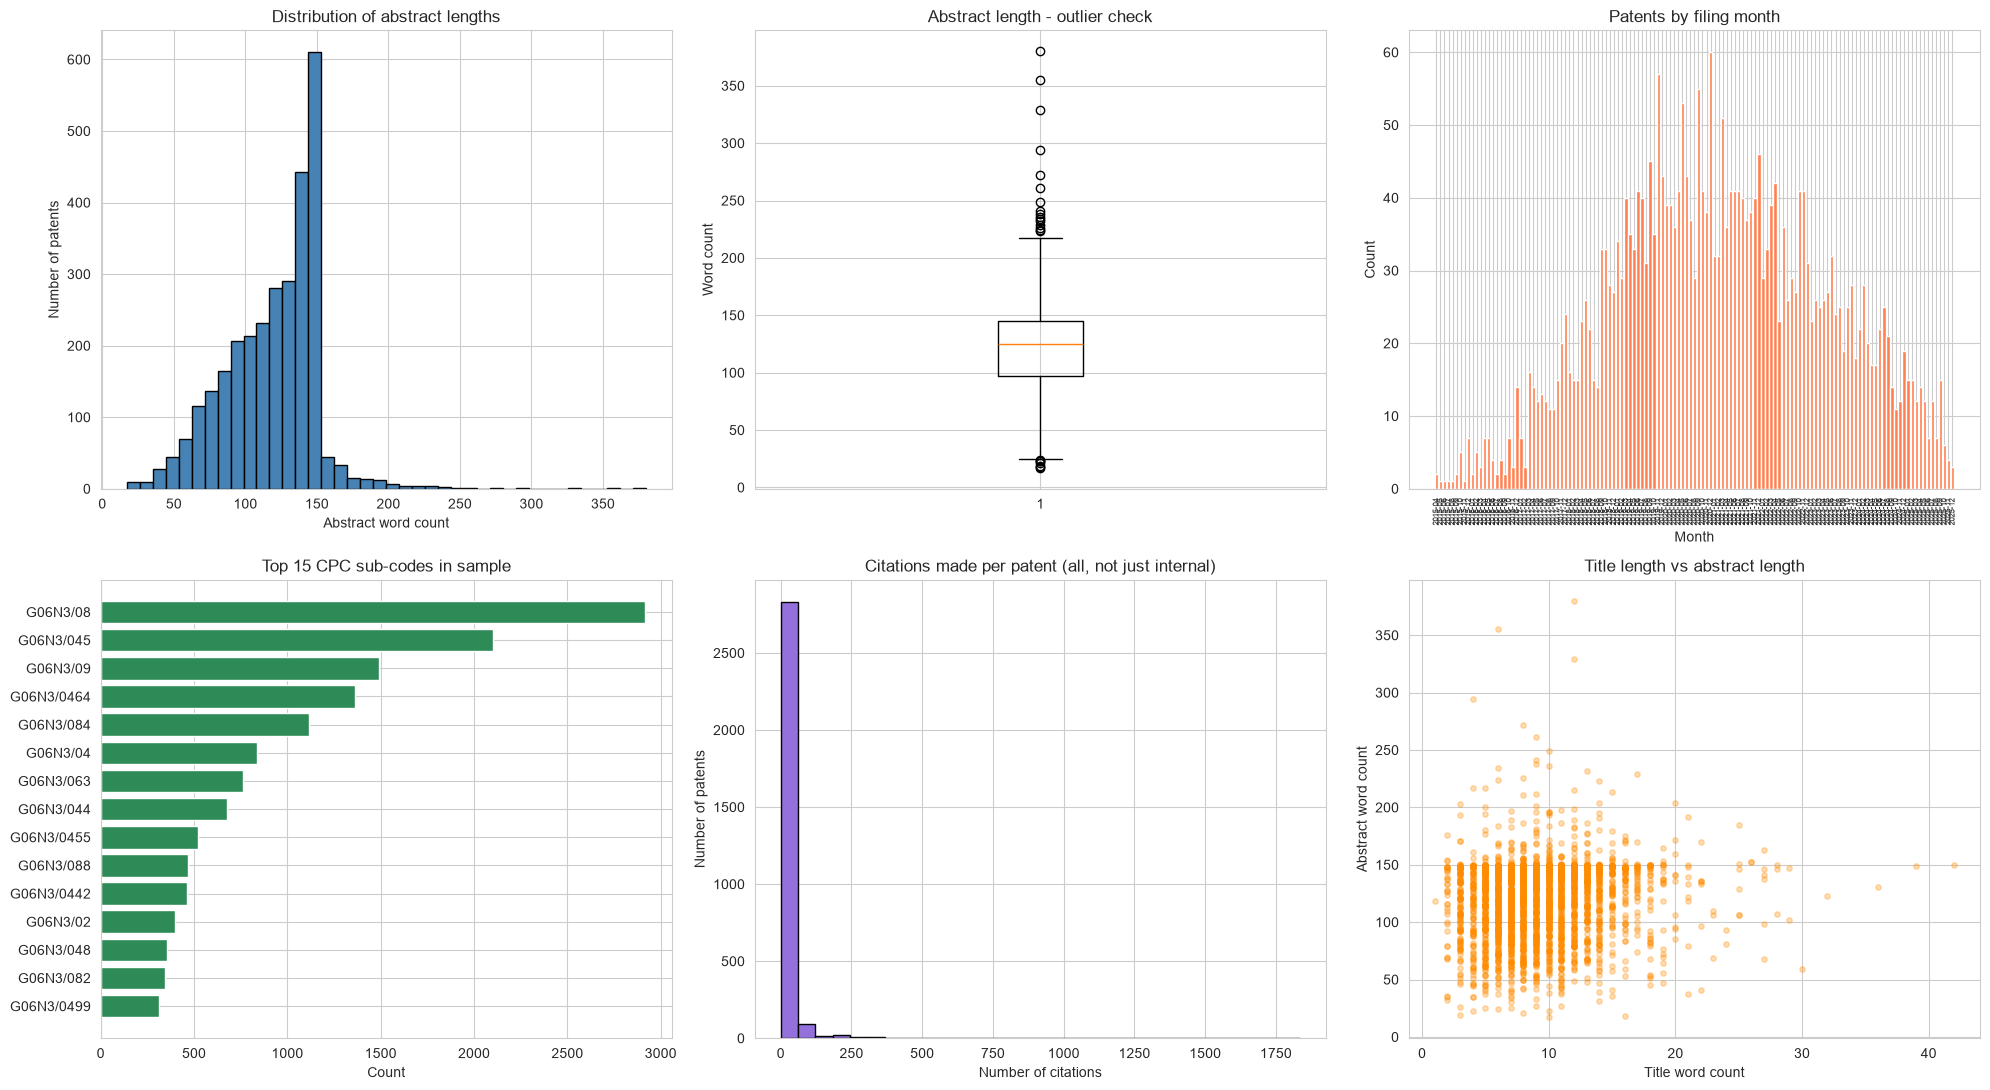


Saved visualization grid to outputs/eda_overview.png

EDA COMPLETE - copy the printed numbers above to share results


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# ============================================================
# STEP 1: Load data
# ============================================================
df = pd.read_csv("../data/raw/patents_g06n3_wide.csv")
print("="*60)
print("SHAPE:", df.shape)
print("COLUMNS:", list(df.columns))
print("="*60)

# ============================================================
# STEP 2: Parse pipe-delimited list columns
# ============================================================
df['cpc_codes'] = df['cpc_codes'].fillna('').apply(lambda x: x.split('|') if x else [])
df['cited_patents'] = df['cited_patents'].fillna('').apply(lambda x: x.split('|') if x else [])

print("\nFORMAT CHECK:")
print("Sample publication_number:", df['publication_number'].iloc[0])
sample_citations = df['cited_patents'].iloc[0]
print("Sample cited_patents:", sample_citations[:3] if len(sample_citations) > 0 else "EMPTY")

# ============================================================
# STEP 3: Missing values check
# ============================================================
print("\nMISSING VALUES PER COLUMN:")
print(df.isnull().sum())
print("\nEmpty abstracts:", (df['abstract'].fillna('').str.strip() == '').sum())
print("Empty titles:", (df['title'].fillna('').str.strip() == '').sum())

before = len(df)
df = df[df['abstract'].fillna('').str.strip() != ''].reset_index(drop=True)
print("\nDropped", before - len(df), "rows with empty abstracts. Remaining:", len(df))

# ============================================================
# STEP 4: Abstract length stats
# ============================================================
df['abstract_word_count'] = df['abstract'].fillna('').apply(lambda x: len(x.split()))
print("\nABSTRACT WORD COUNT STATS:")
print(df['abstract_word_count'].describe())

# ============================================================
# STEP 5: Filing date parsing
# ============================================================
df['filing_date_parsed'] = pd.to_datetime(df['filing_date'], format='%Y%m%d')
print("\nFiling date range:", df['filing_date_parsed'].min(), "to", df['filing_date_parsed'].max())

# ============================================================
# STEP 6: Internal citation pairs (critical for evaluation later)
# ============================================================
sample_ids = set(df['publication_number'])
internal_citation_pairs = []
for _, row in df.iterrows():
    for cited in row['cited_patents']:
        if cited in sample_ids:
            internal_citation_pairs.append((row['publication_number'], cited))

print("\n" + "="*60)
print("INTERNAL CITATION PAIRS (usable for evaluation):", len(internal_citation_pairs))
print("="*60)

# ============================================================
# STEP 7: CPC sub-code breakdown
# ============================================================
all_codes = [code for codes in df['cpc_codes'] for code in codes if code]
code_counts = Counter(all_codes)
total_mentions = len(all_codes)
unique_subcodes = len(code_counts)
print("\nTotal CPC code mentions:", total_mentions)
print("Unique CPC sub-codes:", unique_subcodes)
print("\nTop 10 CPC sub-codes:")
for code, cnt in Counter(code_counts).most_common(10):
    print(" ", code, ":", cnt)

# ============================================================
# STEP 8: Duplicate check
# ============================================================
dupes = df['publication_number'].duplicated().sum()
print("\nDuplicate publication_numbers:", dupes)

# ============================================================
# VISUALIZATIONS
# ============================================================
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(20, 11))

axes[0,0].hist(df['abstract_word_count'], bins=40, edgecolor='black', color='steelblue')
axes[0,0].set_title("Distribution of abstract lengths")
axes[0,0].set_xlabel("Abstract word count")
axes[0,0].set_ylabel("Number of patents")

axes[0,1].boxplot(df['abstract_word_count'])
axes[0,1].set_title("Abstract length - outlier check")
axes[0,1].set_ylabel("Word count")

monthly = df['filing_date_parsed'].dt.to_period('M').value_counts().sort_index()
axes[0,2].bar(monthly.index.astype(str), monthly.values, color='coral')
axes[0,2].set_title("Patents by filing month")
axes[0,2].set_xlabel("Month")
axes[0,2].set_ylabel("Count")
axes[0,2].tick_params(axis='x', rotation=90, labelsize=6)

top_codes = pd.Series(code_counts).sort_values(ascending=False).head(15)
axes[1,0].barh(top_codes.index[::-1], top_codes.values[::-1], color='seagreen')
axes[1,0].set_title("Top 15 CPC sub-codes in sample")
axes[1,0].set_xlabel("Count")

df['num_citations_made'] = df['cited_patents'].apply(len)
axes[1,1].hist(df['num_citations_made'], bins=30, edgecolor='black', color='mediumpurple')
axes[1,1].set_title("Citations made per patent (all, not just internal)")
axes[1,1].set_xlabel("Number of citations")
axes[1,1].set_ylabel("Number of patents")

df['title_word_count'] = df['title'].fillna('').apply(lambda x: len(x.split()))
axes[1,2].scatter(df['title_word_count'], df['abstract_word_count'], alpha=0.3, color='darkorange', s=15)
axes[1,2].set_title("Title length vs abstract length")
axes[1,2].set_xlabel("Title word count")
axes[1,2].set_ylabel("Abstract word count")

plt.tight_layout()
plt.savefig("../outputs/eda_overview.png", dpi=120)
plt.show()

print("\nSaved visualization grid to outputs/eda_overview.png")
print("\n" + "="*60)
print("EDA COMPLETE - copy the printed numbers above to share results")
print("="*60)